In [1]:
from pathlib import Path
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import shutil

from baseline_cnn import BaselineCNN
from utils import train, get_loaders, plot_training_history, plot_sample_predictions, set_seed, plot_confusion_matrix

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print("Using device:", device)

Using device: mps


In [2]:
# personal
DATA_DIR = Path("../data")

#colab
#add cinic_data folder to personal google drive and drop the data downloaded from kaggle
'''
from google.colab import drive
drive.mount('/content/drive')

#DATA_DIR = Path("/content/drive/MyDrive/cinic_data")
DATA_DIR = Path("/content/drive/MyDrive/cinic_subset")

if not os.path.exists('/content/cinic_subset'):
    print("Copying data from drive...", flush=True)
    shutil.copytree(DATA_DIR, '/content/cinic_subset')
    print("Done!", flush=True)
else:
    print("Data already exists locally!", flush=True)


DATA_DIR = Path("/content/cinic_subset")
'''

TRAIN_DIR = DATA_DIR / "train"
VALID_DIR = DATA_DIR / "valid"
TEST_DIR = DATA_DIR / "test"


In [3]:
set_seed(42)

In [4]:
BATCH_SIZE = 128
train_loader, valid_loader, test_loader = get_loaders(train_dir=TRAIN_DIR, valid_dir=VALID_DIR,
                                                      test_dir=TEST_DIR, image_size=32, batch_size=BATCH_SIZE)

## Baseline CNN

In [24]:
checkpoint_dir = 'baseline_models'
os.makedirs(checkpoint_dir, exist_ok=True)

Starting with small BaselineCNN: 

Conv layers: [32], Kernel sizes: [3], FC layers: [10]

In [25]:
model0 = BaselineCNN(input_channels = 3, image_size = 32, conv_channels =[32], kernel_sizes = [3],
                    fc_layers = [10], num_classes = 10)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model0.parameters(), lr=1e-3)

In [26]:
model0_history = train(model0, train_loader, valid_loader, criterion, optimizer, device=device, \
          num_epochs=10, verbose=True, verbose_interval=1, checkpoint_name='baseline_models/model0')

Epoch 1/10 | Train Loss: 2.0489 | Valid Loss: 1.9168 | Valid Acc: 0.2811
Epoch 2/10 | Train Loss: 1.8584 | Valid Loss: 1.8226 | Valid Acc: 0.3131
Epoch 3/10 | Train Loss: 1.7970 | Valid Loss: 1.7737 | Valid Acc: 0.3328
Epoch 4/10 | Train Loss: 1.7680 | Valid Loss: 1.7479 | Valid Acc: 0.3476
Epoch 5/10 | Train Loss: 1.7484 | Valid Loss: 1.7367 | Valid Acc: 0.3524
Epoch 6/10 | Train Loss: 1.7332 | Valid Loss: 1.7292 | Valid Acc: 0.3561
Epoch 7/10 | Train Loss: 1.7219 | Valid Loss: 1.7233 | Valid Acc: 0.3593
Epoch 8/10 | Train Loss: 1.7090 | Valid Loss: 1.7046 | Valid Acc: 0.3624
Epoch 9/10 | Train Loss: 1.7007 | Valid Loss: 1.6857 | Valid Acc: 0.3762
Epoch 10/10 | Train Loss: 1.6901 | Valid Loss: 1.6834 | Valid Acc: 0.3761
Best validation accuracy: 0.3762


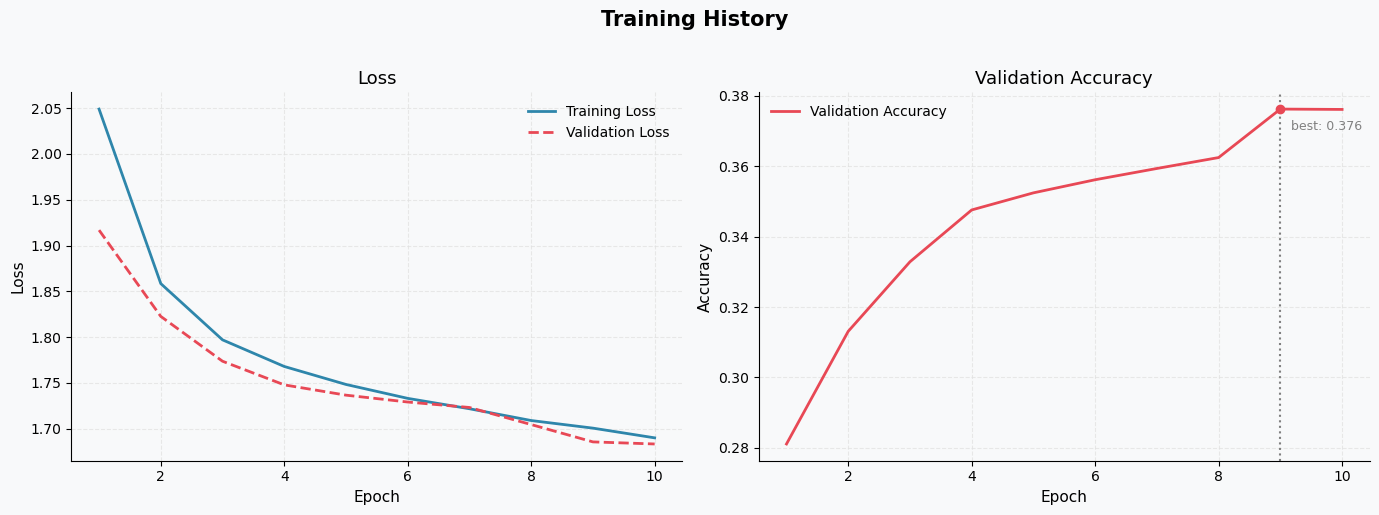

In [27]:
plot_training_history(model0_history)

adding another, larger convolutional layer


Conv layers: [32, 64], Kernel sizes: [3, 3], FC layers: [10]

In [28]:
model1 = BaselineCNN(input_channels = 3, image_size = 32, conv_channels =[32, 64], kernel_sizes = [3, 3],
                    fc_layers = [10], num_classes = 10)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model1.parameters(), lr=1e-3)

In [29]:
model1_history = train(model1, train_loader, valid_loader, criterion, optimizer, device=device, \
          num_epochs=10, verbose=True, verbose_interval=1, checkpoint_name='baseline_models/model1')

Epoch 1/10 | Train Loss: 1.8135 | Valid Loss: 1.7053 | Valid Acc: 0.3566
Epoch 2/10 | Train Loss: 1.5978 | Valid Loss: 1.5571 | Valid Acc: 0.4111
Epoch 3/10 | Train Loss: 1.5295 | Valid Loss: 1.5742 | Valid Acc: 0.4140
Epoch 4/10 | Train Loss: 1.4807 | Valid Loss: 1.5528 | Valid Acc: 0.4266
Epoch 5/10 | Train Loss: 1.4412 | Valid Loss: 1.4345 | Valid Acc: 0.4738
Epoch 6/10 | Train Loss: 1.4124 | Valid Loss: 1.3986 | Valid Acc: 0.4847
Epoch 7/10 | Train Loss: 1.3881 | Valid Loss: 1.6618 | Valid Acc: 0.4120
Epoch 8/10 | Train Loss: 1.3659 | Valid Loss: 1.3843 | Valid Acc: 0.4933
Epoch 9/10 | Train Loss: 1.3492 | Valid Loss: 1.3912 | Valid Acc: 0.4934
Epoch 10/10 | Train Loss: 1.3326 | Valid Loss: 1.6222 | Valid Acc: 0.4445
Best validation accuracy: 0.4934


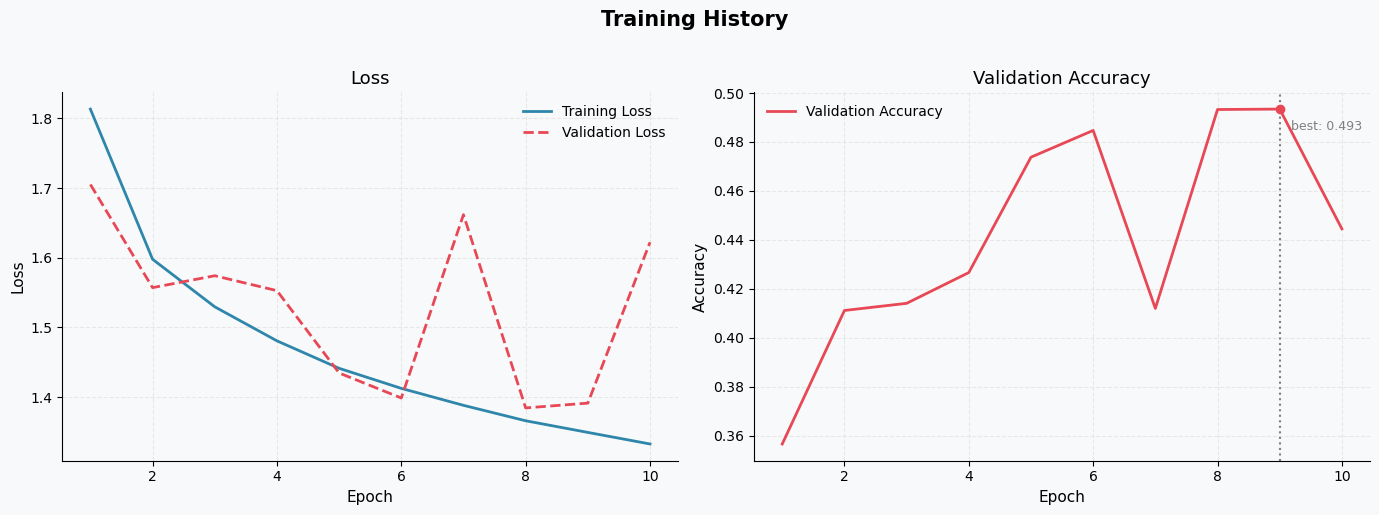

In [30]:
plot_training_history(model1_history)

adding another convolutional layer

In [38]:
model2 = BaselineCNN(input_channels = 3, image_size = 32, conv_channels =[32, 64, 128], kernel_sizes = [3, 3, 3],
                    fc_layers = [10], num_classes = 10)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model2.parameters(), lr=1e-3)

In [39]:
model2_history = train(model2, train_loader, valid_loader, criterion, optimizer, device=device, \
          num_epochs=10, verbose=True, verbose_interval=1, checkpoint_name='baseline_models/model2')

Epoch 1/10 | Train Loss: 1.5870 | Valid Loss: 1.5002 | Valid Acc: 0.4269
Epoch 2/10 | Train Loss: 1.3414 | Valid Loss: 1.3179 | Valid Acc: 0.5047
Epoch 3/10 | Train Loss: 1.2339 | Valid Loss: 1.2580 | Valid Acc: 0.5463
Epoch 4/10 | Train Loss: 1.1647 | Valid Loss: 1.5730 | Valid Acc: 0.4749
Epoch 5/10 | Train Loss: 1.1084 | Valid Loss: 1.2497 | Valid Acc: 0.5439
Epoch 6/10 | Train Loss: 1.0629 | Valid Loss: 1.1626 | Valid Acc: 0.5744
Epoch 7/10 | Train Loss: 1.0259 | Valid Loss: 1.1625 | Valid Acc: 0.5853
Epoch 8/10 | Train Loss: 0.9964 | Valid Loss: 1.1634 | Valid Acc: 0.5740
Epoch 9/10 | Train Loss: 0.9677 | Valid Loss: 1.0770 | Valid Acc: 0.6148
Epoch 10/10 | Train Loss: 0.9357 | Valid Loss: 1.1353 | Valid Acc: 0.5906
Best validation accuracy: 0.6148


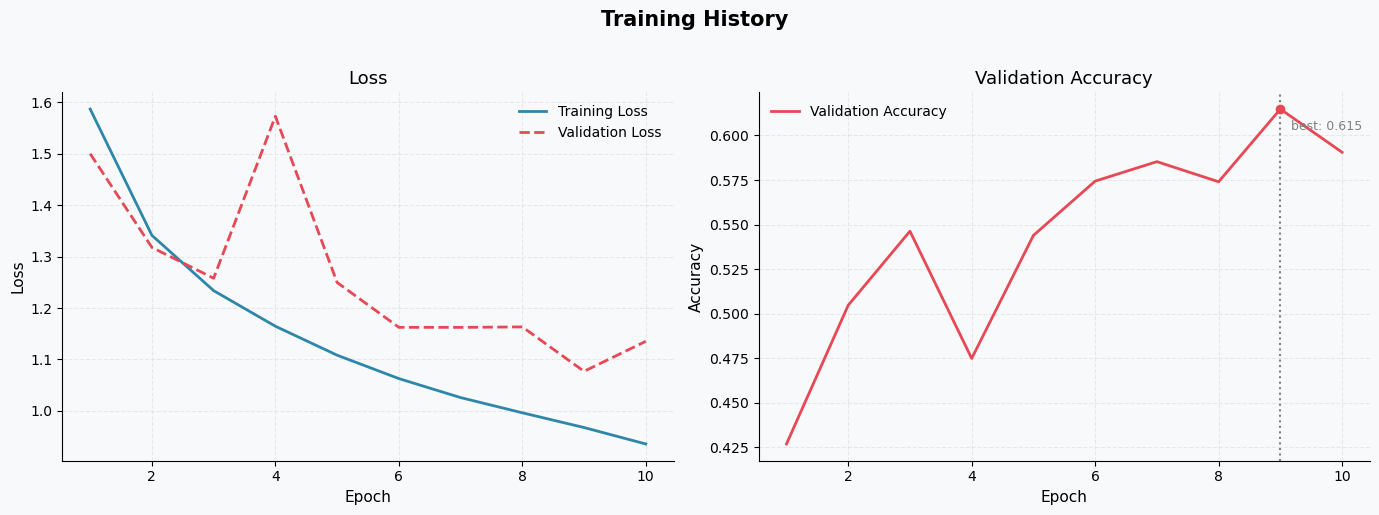

In [40]:
plot_training_history(model2_history)

In [ ]:
model3 = BaselineCNN(input_channels = 3, image_size = 32, conv_channels =[64, 128, 256], kernel_sizes = [3, 3, 3],
                    fc_layers = [10], num_classes = 10)

criterion = torch.nn.CrossaEntropyLoss()
optimizer = torch.optim.Adam(model3.parameters(), lr=1e-3)

In [43]:
model3_history = train(model3, train_loader, valid_loader, criterion, optimizer, device=device, \
          num_epochs=10, verbose=True, verbose_interval=1, checkpoint_name='baseline_models/model3')

Epoch 1/10 | Train Loss: 1.4961 | Valid Loss: 1.4552 | Valid Acc: 0.4633
Epoch 2/10 | Train Loss: 1.2550 | Valid Loss: 1.3446 | Valid Acc: 0.5082
Epoch 3/10 | Train Loss: 1.1498 | Valid Loss: 1.2187 | Valid Acc: 0.5628
Epoch 4/10 | Train Loss: 1.0765 | Valid Loss: 1.0671 | Valid Acc: 0.6166
Epoch 5/10 | Train Loss: 1.0127 | Valid Loss: 1.1805 | Valid Acc: 0.5817
Epoch 6/10 | Train Loss: 0.9626 | Valid Loss: 1.1017 | Valid Acc: 0.6059
Epoch 7/10 | Train Loss: 0.9101 | Valid Loss: 1.1205 | Valid Acc: 0.6012
Epoch 8/10 | Train Loss: 0.8641 | Valid Loss: 1.1205 | Valid Acc: 0.6054
Epoch 9/10 | Train Loss: 0.8229 | Valid Loss: 0.9862 | Valid Acc: 0.6510
Epoch 10/10 | Train Loss: 0.7764 | Valid Loss: 1.0494 | Valid Acc: 0.6285
Best validation accuracy: 0.6510


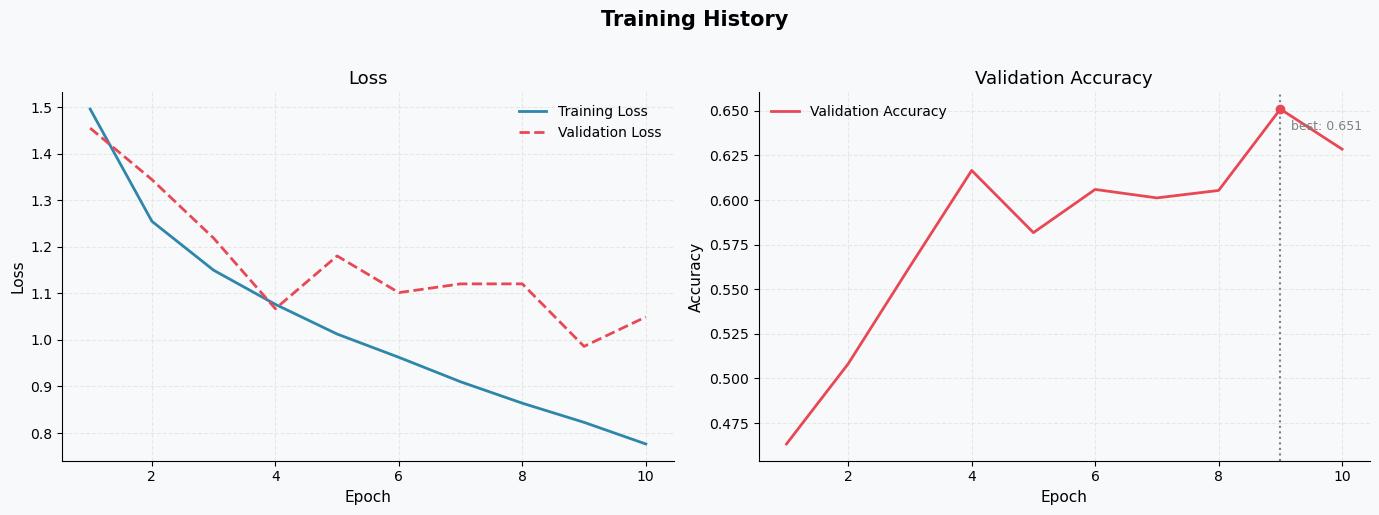

In [44]:
plot_training_history(model3_history)

In [50]:
model4 = BaselineCNN(input_channels = 3, image_size = 32, conv_channels =[64, 128, 256], kernel_sizes = [3, 3, 3],
                    fc_layers = [64], num_classes = 10)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model4.parameters(), lr=1e-3)

In [51]:
model4_history = train(model4, train_loader, valid_loader, criterion, optimizer, device=device, \
          num_epochs=10, verbose=True, verbose_interval=1, checkpoint_name='baseline_models/model4')

Epoch 1/10 | Train Loss: 1.4720 | Valid Loss: 1.4034 | Valid Acc: 0.4901
Epoch 2/10 | Train Loss: 1.2195 | Valid Loss: 1.2508 | Valid Acc: 0.5428
Epoch 3/10 | Train Loss: 1.1094 | Valid Loss: 1.1269 | Valid Acc: 0.5915
Epoch 4/10 | Train Loss: 1.0263 | Valid Loss: 1.1546 | Valid Acc: 0.5891
Epoch 5/10 | Train Loss: 0.9622 | Valid Loss: 1.1358 | Valid Acc: 0.5970
Epoch 6/10 | Train Loss: 0.9029 | Valid Loss: 1.1543 | Valid Acc: 0.6059
Epoch 7/10 | Train Loss: 0.8543 | Valid Loss: 1.0571 | Valid Acc: 0.6215
Epoch 8/10 | Train Loss: 0.8039 | Valid Loss: 1.0062 | Valid Acc: 0.6436
Epoch 9/10 | Train Loss: 0.7621 | Valid Loss: 0.9478 | Valid Acc: 0.6666
Epoch 10/10 | Train Loss: 0.7141 | Valid Loss: 0.9747 | Valid Acc: 0.6586
Best validation accuracy: 0.6666


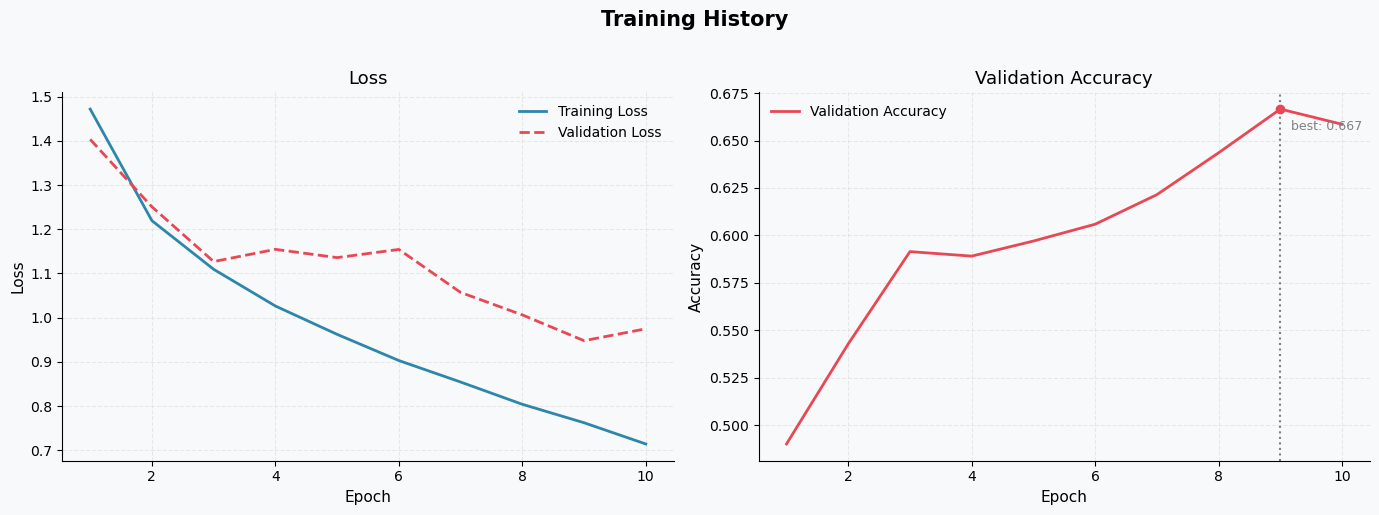

In [52]:
plot_training_history(model4_history)

In [54]:
model5 = BaselineCNN(input_channels = 3, image_size = 32, conv_channels =[64, 128, 256], kernel_sizes = [3, 3, 3],
                    fc_layers = [128, 64], num_classes = 10)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model5.parameters(), lr=1e-3)

In [56]:
model5_history = train(model5, train_loader, valid_loader, criterion, optimizer, device=device, \
          num_epochs=10, verbose=True, verbose_interval=1, checkpoint_name='baseline_models/model5')

Epoch 1/10 | Train Loss: 1.4316 | Valid Loss: 1.3474 | Valid Acc: 0.4971
Epoch 2/10 | Train Loss: 1.2149 | Valid Loss: 1.1959 | Valid Acc: 0.5637
Epoch 3/10 | Train Loss: 1.1073 | Valid Loss: 1.2082 | Valid Acc: 0.5607
Epoch 4/10 | Train Loss: 1.0238 | Valid Loss: 1.1199 | Valid Acc: 0.5981
Epoch 5/10 | Train Loss: 0.9630 | Valid Loss: 1.0066 | Valid Acc: 0.6331
Epoch 6/10 | Train Loss: 0.8994 | Valid Loss: 1.0641 | Valid Acc: 0.6198
Epoch 7/10 | Train Loss: 0.8456 | Valid Loss: 1.1286 | Valid Acc: 0.6030
Epoch 8/10 | Train Loss: 0.7994 | Valid Loss: 1.0838 | Valid Acc: 0.6202
Epoch 9/10 | Train Loss: 0.7504 | Valid Loss: 0.9739 | Valid Acc: 0.6602
Epoch 10/10 | Train Loss: 0.7066 | Valid Loss: 1.0824 | Valid Acc: 0.6445
Best validation accuracy: 0.6602


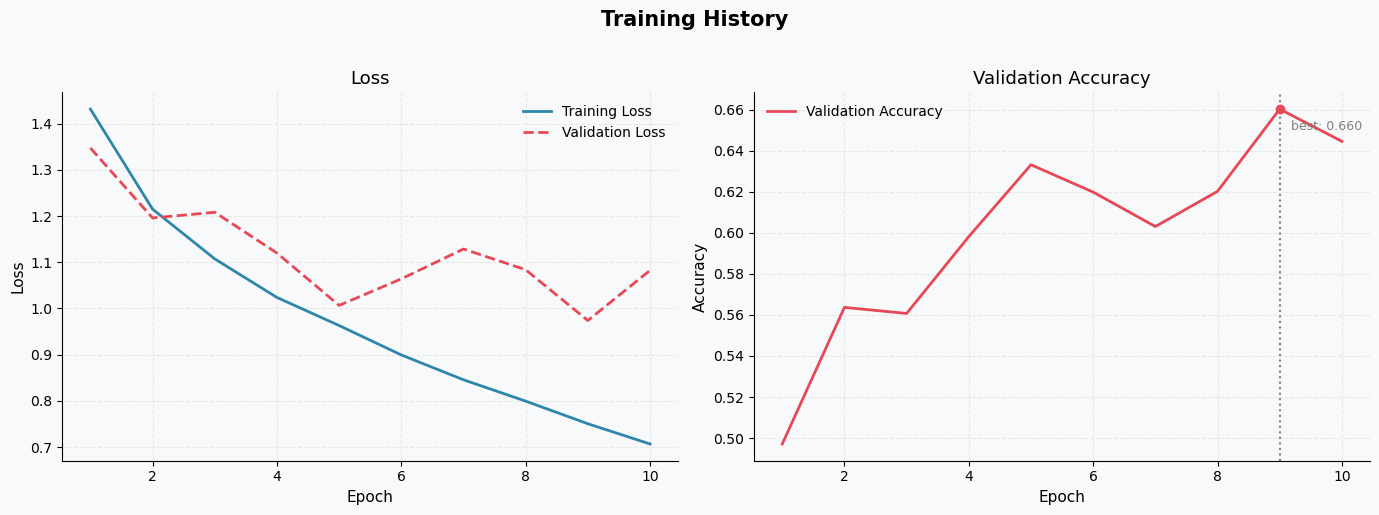

In [57]:
plot_training_history(model5_history)

In [58]:
model6 = BaselineCNN(input_channels = 3, image_size = 32, conv_channels =[64, 128, 256, 512], kernel_sizes = [3, 3, 3, 3],
                    fc_layers = [128, 64], num_classes = 10)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model6.parameters(), lr=1e-3)

In [59]:
model6_history = train(model6, train_loader, valid_loader, criterion, optimizer, device=device, \
          num_epochs=10, verbose=True, verbose_interval=1, checkpoint_name='baseline_models/model6')

Epoch 1/10 | Train Loss: 1.3586 | Valid Loss: 1.2011 | Valid Acc: 0.5608
Epoch 2/10 | Train Loss: 1.0532 | Valid Loss: 1.1675 | Valid Acc: 0.5876
Epoch 3/10 | Train Loss: 0.9184 | Valid Loss: 0.9578 | Valid Acc: 0.6625
Epoch 4/10 | Train Loss: 0.8144 | Valid Loss: 1.0948 | Valid Acc: 0.6214
Epoch 5/10 | Train Loss: 0.7217 | Valid Loss: 0.9407 | Valid Acc: 0.6696
Epoch 6/10 | Train Loss: 0.6316 | Valid Loss: 0.9385 | Valid Acc: 0.6793
Epoch 7/10 | Train Loss: 0.5464 | Valid Loss: 1.1089 | Valid Acc: 0.6638
Epoch 8/10 | Train Loss: 0.4595 | Valid Loss: 1.1784 | Valid Acc: 0.6533
Epoch 9/10 | Train Loss: 0.3706 | Valid Loss: 1.0066 | Valid Acc: 0.6971
Epoch 10/10 | Train Loss: 0.2932 | Valid Loss: 1.1053 | Valid Acc: 0.6927
Best validation accuracy: 0.6971


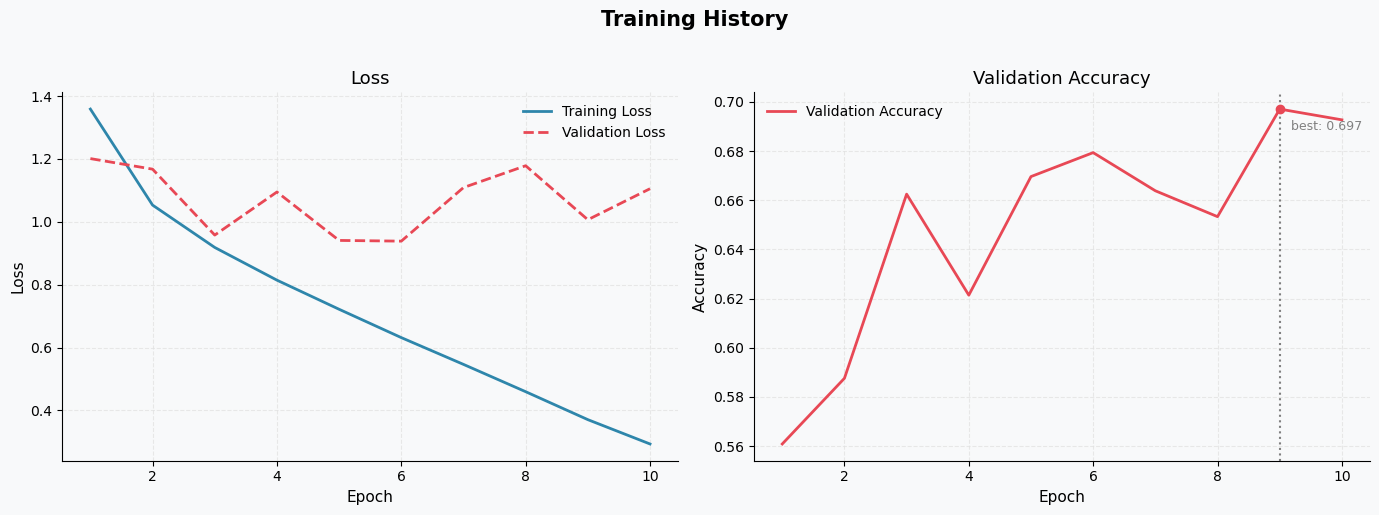

In [60]:
plot_training_history(model6_history)

In [70]:
model7 = BaselineCNN(input_channels = 3, image_size = 32, conv_channels =[64, 128, 256, 512], kernel_sizes = [3, 3, 3, 3],
                    fc_layers = [128, 64, 32], num_classes = 10)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model7.parameters(), lr=1e-3)

In [71]:
model7_history = train(model7, train_loader, valid_loader, criterion, optimizer, device=device, \
          num_epochs=10, verbose=True, verbose_interval=1, checkpoint_name='baseline_models/model7')

Epoch 1/10 | Train Loss: 1.4064 | Valid Loss: 1.2929 | Valid Acc: 0.5249
Epoch 2/10 | Train Loss: 1.0885 | Valid Loss: 1.1448 | Valid Acc: 0.5851
Epoch 3/10 | Train Loss: 0.9445 | Valid Loss: 1.0424 | Valid Acc: 0.6282
Epoch 4/10 | Train Loss: 0.8367 | Valid Loss: 0.9652 | Valid Acc: 0.6555
Epoch 5/10 | Train Loss: 0.7449 | Valid Loss: 0.9374 | Valid Acc: 0.6722
Epoch 6/10 | Train Loss: 0.6579 | Valid Loss: 1.0713 | Valid Acc: 0.6444
Epoch 7/10 | Train Loss: 0.5748 | Valid Loss: 0.9995 | Valid Acc: 0.6752
Epoch 8/10 | Train Loss: 0.4867 | Valid Loss: 1.1018 | Valid Acc: 0.6603
Epoch 9/10 | Train Loss: 0.4057 | Valid Loss: 1.2486 | Valid Acc: 0.6362
Epoch 10/10 | Train Loss: 0.3332 | Valid Loss: 1.0981 | Valid Acc: 0.6908
Best validation accuracy: 0.6908


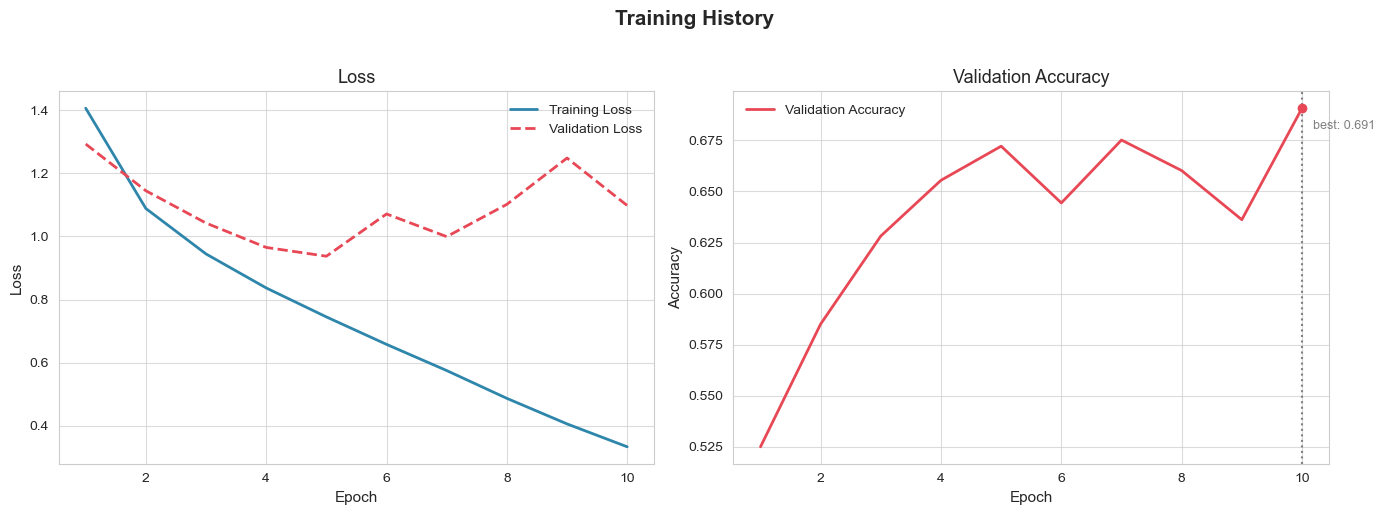

In [75]:
plot_training_history(model7_history)

In [79]:
model8 = BaselineCNN(input_channels = 3, image_size = 32, conv_channels =[64, 128, 256, 512], kernel_sizes = [5, 3, 3, 3],
                    fc_layers = [128, 64], num_classes = 10)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model8.parameters(), lr=1e-3)

In [80]:
model8_history = train(model8, train_loader, valid_loader, criterion, optimizer, device=device, \
          num_epochs=10, verbose=True, verbose_interval=1, checkpoint_name='baseline_models/model8')

Epoch 1/10 | Train Loss: 1.3758 | Valid Loss: 1.3309 | Valid Acc: 0.5286
Epoch 2/10 | Train Loss: 1.0607 | Valid Loss: 1.0985 | Valid Acc: 0.6130
Epoch 3/10 | Train Loss: 0.9066 | Valid Loss: 1.0181 | Valid Acc: 0.6364
Epoch 4/10 | Train Loss: 0.7802 | Valid Loss: 0.9926 | Valid Acc: 0.6568
Epoch 5/10 | Train Loss: 0.6584 | Valid Loss: 1.0057 | Valid Acc: 0.6572
Epoch 6/10 | Train Loss: 0.5316 | Valid Loss: 1.1039 | Valid Acc: 0.6487
Epoch 7/10 | Train Loss: 0.4122 | Valid Loss: 1.1454 | Valid Acc: 0.6628
Epoch 8/10 | Train Loss: 0.3133 | Valid Loss: 1.1640 | Valid Acc: 0.6788
Epoch 9/10 | Train Loss: 0.2327 | Valid Loss: 1.2581 | Valid Acc: 0.6714
Epoch 10/10 | Train Loss: 0.1801 | Valid Loss: 1.4654 | Valid Acc: 0.6572
Best validation accuracy: 0.6788


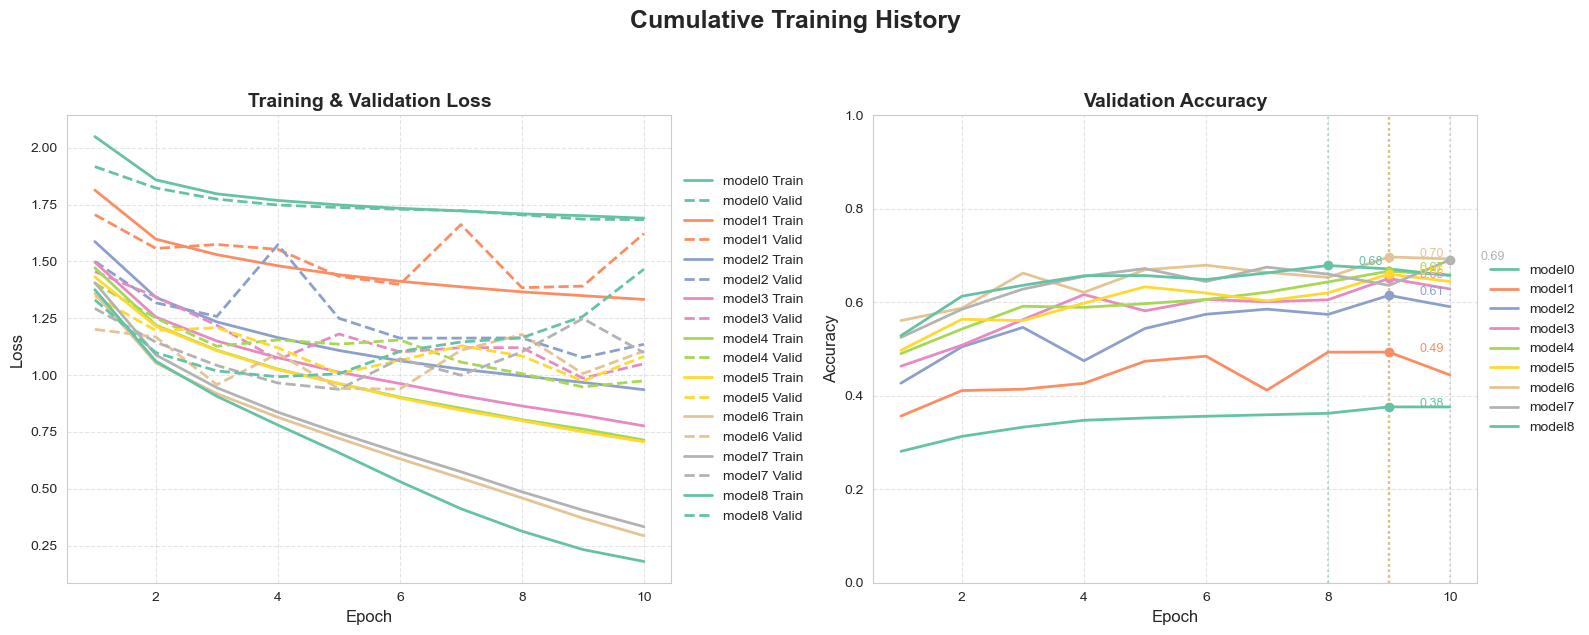

In [83]:
all_metrics_history = {
    "model0": model0_history,
    "model1": model1_history,
    "model2": model2_history,
    "model3": model3_history,
    "model4": model4_history,
    "model5": model5_history,
    "model6": model6_history,
    "model7": model7_history,
    "model8": model8_history
}

plot_cumulative_training_history(all_metrics_history)